Loading data...
Data loaded in 2.09 seconds

Training data shape: (61609, 62), Test data shape: (41074, 61)

Exploring data distributions...


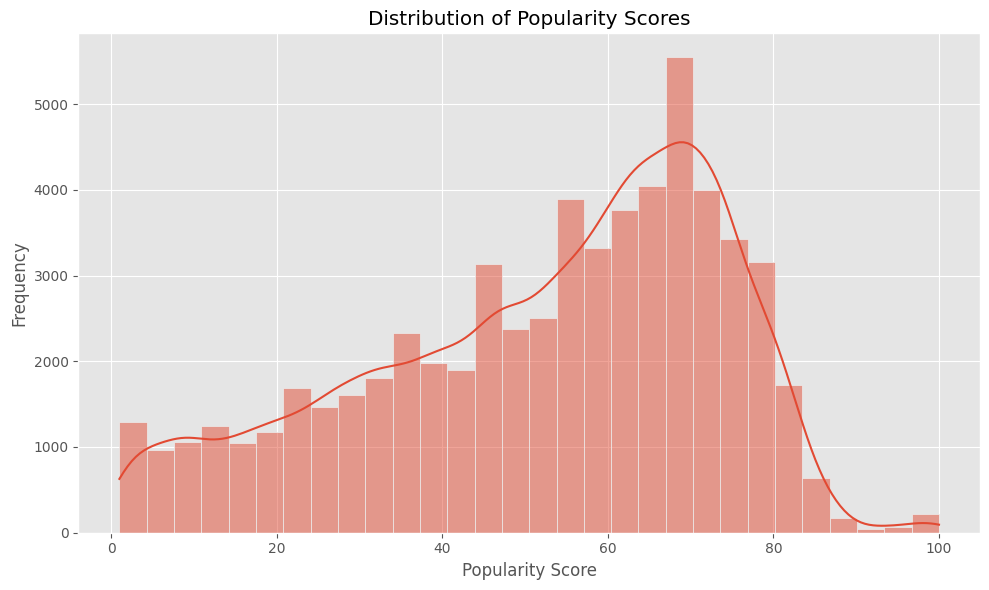

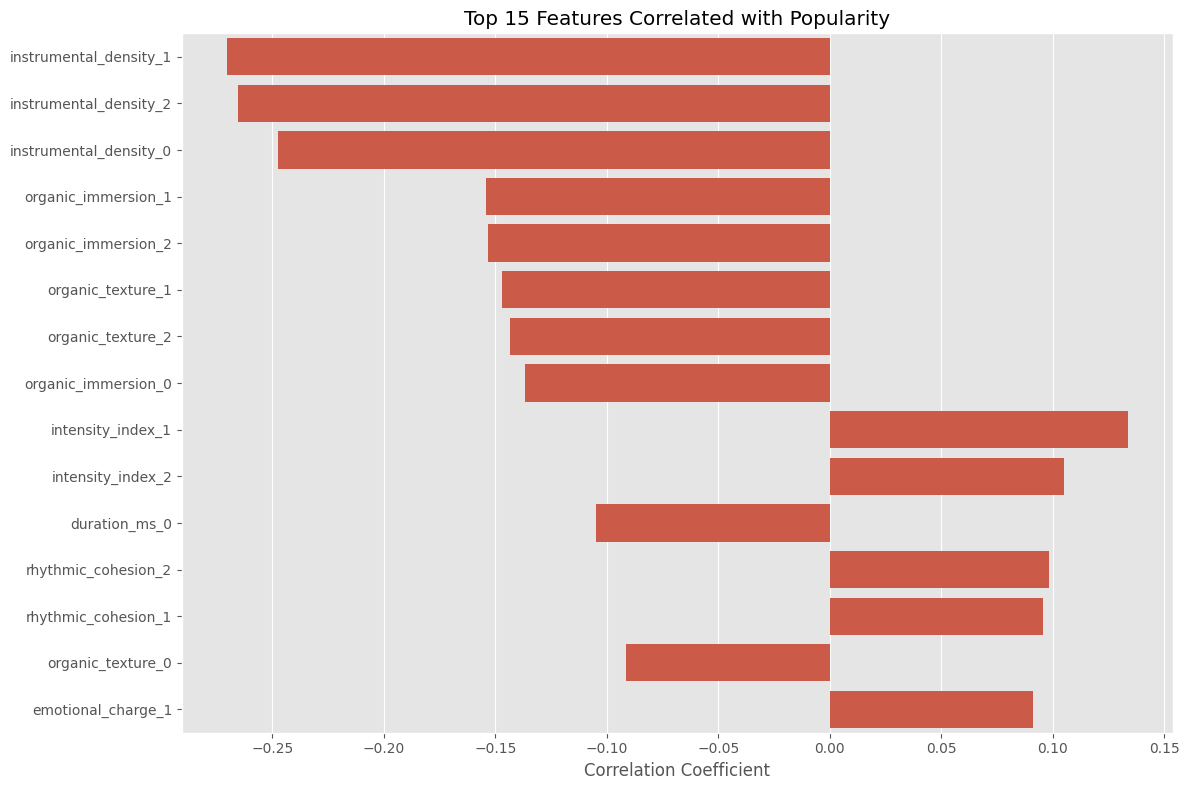

Data exploration completed in 2.31 seconds

Preprocessing data...

Performing feature engineering...

Handling outliers...
Preprocessing completed in 1.66 seconds

Preparing data for modeling...
Using 73 numeric features and 0 categorical features
Model preparation completed in 0.20 seconds

Training Random Forest model...
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   4.6s


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   27.9s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.6min finished


[Pipeline] ............. (step 2 of 2) Processing model, total= 2.6min
Model training completed in 161.54 seconds

Evaluating model...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


Validation RMSE: 15.0802
Validation MAE: 11.5960
Validation R²: 0.5117
Evaluation completed in 2.32 seconds


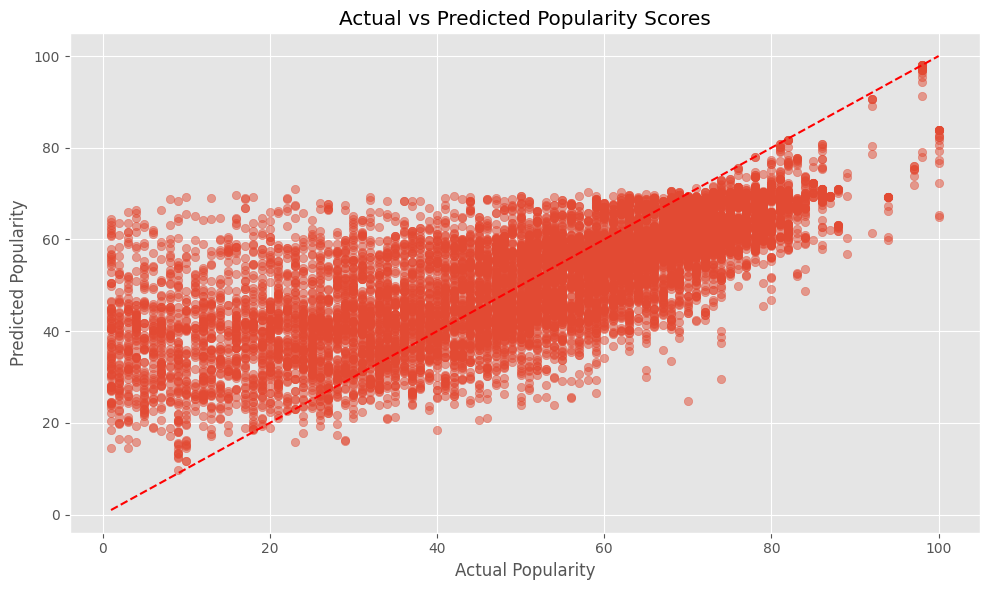

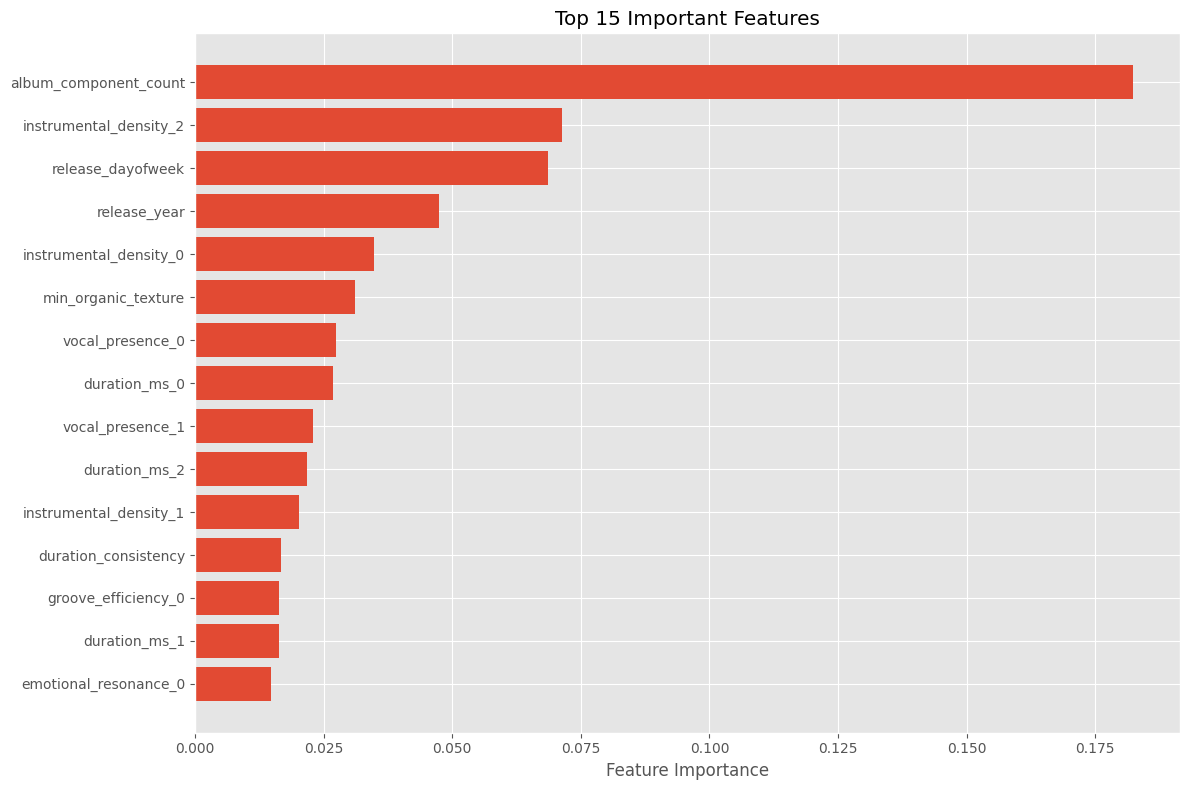

Feature importance analysis completed in 0.36 seconds

Making predictions on test data...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Predictions and submission completed in 3.40 seconds
Submission file created: submission8.csv

Total execution time: 174.33 seconds (2.91 minutes)

Random Forest model training and prediction completed!


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.3s finished


In [1]:
#Random Forest - Optimized for Performance (Fixed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time
import warnings
warnings.filterwarnings('ignore')

# Start execution timer
start_time = time.time()

# Set the style for visualizations - reduced overhead
plt.style.use('ggplot')

# Load the data with optimized settings
print("Loading data...")
load_time = time.time()
train_data = pd.read_csv('train.csv', low_memory=False, dtype_backend='numpy_nullable')
test_data = pd.read_csv('test.csv', low_memory=False, dtype_backend='numpy_nullable')
print(f"Data loaded in {time.time() - load_time:.2f} seconds")

# Display minimal information
print(f"\nTraining data shape: {train_data.shape}, Test data shape: {test_data.shape}")

# Data exploration - only essential visualizations
print("\nExploring data distributions...")
explore_time = time.time()

# Only create target distribution plot - most important for understanding
plt.figure(figsize=(10, 6))
sns.histplot(train_data['target'], kde=True, bins=30)
plt.title('Distribution of Popularity Scores')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Calculate correlations with target efficiently - top correlations only
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')

# Compute all correlations at once - more efficient
correlations = []
if len(numeric_cols) > 0:
    corr_matrix = train_data[numeric_cols + ['target']].corr()
    target_corrs = corr_matrix['target'].drop('target')
    correlations = [(col, corr) for col, corr in target_corrs.items() if not np.isnan(corr)]
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    top_features = correlations[:15]

    plt.figure(figsize=(12, 8))
    feature_names = [x[0] for x in top_features]
    correlation_values = [x[1] for x in top_features]
    sns.barplot(x=correlation_values, y=feature_names)
    plt.title('Top 15 Features Correlated with Popularity')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()

print(f"Data exploration completed in {time.time() - explore_time:.2f} seconds")

# Data preprocessing - optimized
print("\nPreprocessing data...")
preprocess_time = time.time()

# Optimize column identification for later use - do this once
id_columns = ['id', 'track_identifier']
target_column = 'target'

# Add train/test indicators first
train_data['is_train'] = 1
test_data['is_train'] = 0

# Add target to test data before filtering columns
test_data[target_column] = np.nan

# Only keep essential columns to reduce memory usage - 
# Handle train and test separately to avoid KeyError
train_essential_columns = [col for col in train_data.columns if col not in id_columns or col == 'id']
test_essential_columns = [col for col in test_data.columns if col not in id_columns or col == 'id']

train_data = train_data[train_essential_columns]
test_data = test_data[test_essential_columns]

# Combine train and test more efficiently
combined_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

# Handle missing values more efficiently
for col in combined_data.columns:
    if combined_data[col].dtype in ['int64', 'float64']:
        # Compute median only once per column
        train_median = combined_data.loc[combined_data['is_train'] == 1, col].median()
        combined_data[col] = combined_data[col].fillna(train_median)
    elif combined_data[col].dtype == 'object':
        # Compute mode only once per column
        if not combined_data.loc[combined_data['is_train'] == 1, col].mode().empty:
            mode_val = combined_data.loc[combined_data['is_train'] == 1, col].mode()[0]
            combined_data[col] = combined_data[col].fillna(mode_val)
        else:
            combined_data[col] = combined_data[col].fillna("Unknown")

# Feature engineering - more efficient implementation
print("\nPerforming feature engineering...")

# Convert timestamp once and extract all features in one go
if 'publication_timestamp' in combined_data.columns:
    combined_data['publication_timestamp'] = pd.to_datetime(combined_data['publication_timestamp'], errors='coerce')
    # Extract all date features at once
    combined_data['release_year'] = combined_data['publication_timestamp'].dt.year
    combined_data['release_month'] = combined_data['publication_timestamp'].dt.month
    combined_data['release_day'] = combined_data['publication_timestamp'].dt.day
    combined_data['release_dayofweek'] = combined_data['publication_timestamp'].dt.dayofweek
    # Drop the original column to save memory
    combined_data.drop('publication_timestamp', axis=1, inplace=True)

# More efficient audio feature aggregation
feature_prefixes = ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'emotional_charge']
for prefix in feature_prefixes:
    cols = [col for col in combined_data.columns if prefix in col]
    if cols:
        # Calculate all aggregates at once as DataFrame operations
        combined_data[f'avg_{prefix}'] = combined_data[cols].mean(axis=1)
        combined_data[f'max_{prefix}'] = combined_data[cols].max(axis=1)
        combined_data[f'min_{prefix}'] = combined_data[cols].min(axis=1)
        # Use existing columns for calculation
        combined_data[f'range_{prefix}'] = combined_data[f'max_{prefix}'] - combined_data[f'min_{prefix}']

# Create interaction features efficiently
if 'avg_intensity_index' in combined_data.columns and 'avg_rhythmic_cohesion' in combined_data.columns:
    combined_data['energy_dance_product'] = combined_data['avg_intensity_index'] * combined_data['avg_rhythmic_cohesion']

if 'avg_organic_texture' in combined_data.columns and 'avg_emotional_charge' in combined_data.columns:
    # Vectorized operation
    combined_data['acoustic_emotional_ratio'] = combined_data['avg_organic_texture'] / (combined_data['avg_emotional_charge'] + 0.001)

# Simple artist count extraction if needed
if 'creator_collective' in combined_data.columns:
    combined_data['artist_count'] = combined_data['creator_collective'].str.count(',') + 1
    # Drop original column to save memory if it's not needed later
    combined_data.drop('creator_collective', axis=1, inplace=True)

# Efficient outlier handling - use vectorized operations
print("\nHandling outliers...")
numeric_features = combined_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col not in ['is_train', target_column, 'id']]

# Process all columns together for efficiency
train_mask = combined_data['is_train'] == 1
for col in numeric_features:
    Q1 = combined_data.loc[train_mask, col].quantile(0.25)
    Q3 = combined_data.loc[train_mask, col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Vectorized capping
    combined_data[col] = combined_data[col].clip(lower=lower_bound, upper=upper_bound)

print(f"Preprocessing completed in {time.time() - preprocess_time:.2f} seconds")

# Split back into train and test
train_processed = combined_data[combined_data['is_train'] == 1].drop('is_train', axis=1)
test_processed = combined_data[combined_data['is_train'] == 0].drop(['is_train', target_column], axis=1)

# Prepare data for modeling efficiently
print("\nPreparing data for modeling...")
model_prep_time = time.time()

# Define features efficiently
categorical_features = train_processed.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in id_columns]

numeric_features = train_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col != target_column and col not in id_columns]

print(f"Using {len(numeric_features)} numeric features and {len(categorical_features)} categorical features")

# Prepare X and y efficiently
drop_cols = [col for col in id_columns + [target_column] if col in train_processed.columns]
X = train_processed.drop(drop_cols, axis=1)
y = train_processed[target_column]

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create preprocessing pipeline with optimized settings
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    n_jobs=-1,  # Parallelize preprocessing
    verbose=True    # Changed from 1 to True for boolean parameter
)

print(f"Model preparation completed in {time.time() - model_prep_time:.2f} seconds")

# Train Random Forest model with performance optimization
print("\nTraining Random Forest model...")
training_time = time.time()

# Optimized Random Forest with parallel processing
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,        # Use all available cores
    verbose=1,        # This is fine as RandomForestRegressor accepts integers for verbose
    warm_start=False  # More efficient for single training
)

# Create and fit pipeline with efficient memory usage - FIX: change verbose=1 to verbose=True
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
], verbose=True)  # Changed from 1 to True for boolean parameter

pipeline.fit(X_train, y_train)

print(f"Model training completed in {time.time() - training_time:.2f} seconds")

# Evaluate model
print("\nEvaluating model...")
eval_time = time.time()
y_pred_val = pipeline.predict(X_val)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R²: {r2:.4f}")
print(f"Evaluation completed in {time.time() - eval_time:.2f} seconds")

# Visualize actual vs predicted - simplified for performance
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity Scores')
plt.tight_layout()
plt.show()

# Feature importance - optimized to only compute for top features
importance_time = time.time()

# Get feature names without generating all of them
feature_names = []
# Add numeric feature names
feature_names.extend(numeric_features)
# Add transformed categorical feature names
if len(categorical_features) > 0:
    # Get one-hot encoded feature names more efficiently
    try:
        cat_feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
        feature_names.extend(cat_feature_names)
    except:
        # Fallback if get_feature_names_out fails
        for cat in categorical_features:
            feature_names.append(f"cat_{cat}")

# Only sort and display top 15 features for efficiency
feature_importances = pipeline.named_steps['model'].feature_importances_
top_indices = np.argsort(feature_importances)[-15:]  # Get indices of top 15 features

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_indices)), feature_importances[top_indices], align='center')
# Only access feature names for the features we need
displayed_names = []
for i in top_indices:
    if i < len(feature_names):
        displayed_names.append(feature_names[i])
    else:
        displayed_names.append(f"Feature_{i}") 
plt.yticks(range(len(top_indices)), displayed_names)
plt.xlabel('Feature Importance')
plt.title('Top 15 Important Features')
plt.tight_layout()
plt.show()

print(f"Feature importance analysis completed in {time.time() - importance_time:.2f} seconds")

# Make predictions on test data
print("\nMaking predictions on test data...")
prediction_time = time.time()

# Optimize prediction - only keep necessary columns
test_id = test_processed['id'].copy()
test_features = test_processed.drop([col for col in id_columns if col in test_processed.columns], axis=1, errors='ignore')
test_predictions = pipeline.predict(test_features)

# Create submission file efficiently
submission = pd.DataFrame({
    'id': test_id,
    'target': test_predictions
})

# Ensure predictions are within valid range (0-100)
submission['target'] = submission['target'].clip(0, 100)

# Save submission file
submission.to_csv('submission11.csv', index=False)
print(f"Predictions and submission completed in {time.time() - prediction_time:.2f} seconds")
print("Submission file created: submission8.csv")

# Print total execution time
total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print("\nRandom Forest model training and prediction completed!")